In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
data = pd.read_csv('chr1.filtered.processed.mpileup')

In [3]:
data.head()

,chrom,pos,ref,coverage,non_ref_reads,error_rate
0,1,131335,C,21,0,0.0
1,1,131336,A,22,0,0.0
2,1,131337,G,22,0,0.0
3,1,131338,G,21,0,0.0
4,1,131339,T,22,0,0.0


In [4]:
data.shape

(7199422, 6)

In [5]:
data[data['error_rate'] > 0].shape

(657586, 6)

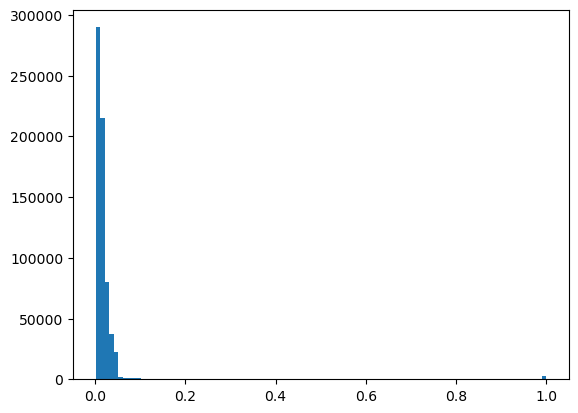

In [6]:
plt.hist(data[data['error_rate'] > 0].iloc[:,-1], bins = 100)
plt.show()

## filter out all error rates above 1%

In [7]:
data = data[data['error_rate'] <= 0.01]

## subsample so that there are the ratio of absolute zero sites is 10%

In [8]:
data_zeros = data[data['error_rate'] == 0]
data_nonzero = data[data['error_rate'] > 0]

num_nonzero_sites = data[data['error_rate'] > 0].shape[0]

target_zero_site_num = int(num_nonzero_sites * 0.1)

random_subsample_idx = np.random.randint(low = 0,
                                     high = data_zeros.shape[0],
                                     size = target_zero_site_num,
                                     dtype = int)

data_zeros_subsampled = data_zeros.iloc[random_subsample_idx,:]

In [9]:
data_balanced = pd.concat([data_zeros_subsampled, data_nonzero], axis = 0)

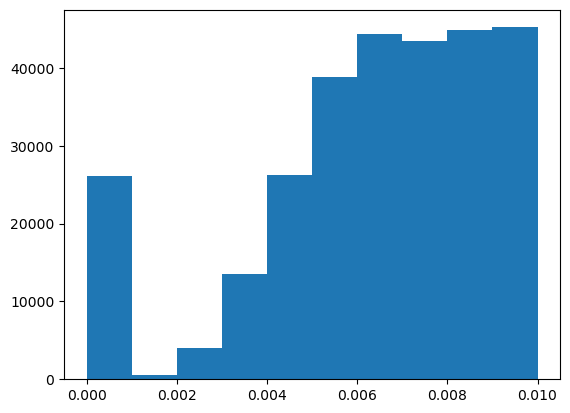

In [10]:
plt.hist(data_balanced['error_rate'])
plt.show()

In [11]:
data_balanced

,chrom,pos,ref,coverage,non_ref_reads,error_rate
6348387,1,212274153,A,97,0,0.000000
3979576,1,150900355,G,140,0,0.000000
4180300,1,153270560,A,187,0,0.000000
642040,1,16477590,A,23,0,0.000000
5210841,1,170024436,A,86,0,0.000000
...,...,...,...,...,...,...
7199036,1,249212567,A,146,1,0.006849
7199047,1,249212578,T,144,1,0.006944
7199056,1,249212587,T,135,1,0.007407
7199063,1,249212594,G,130,1,0.007692


#### The next step is maybe to randomly subsample this balanced dataset, so that a smaller loci list is created (or maybe this is okay???)

In [12]:
data_balanced.to_csv('data_balanced_full.csv', index = False)  # save the full balanced data

Subsample to a dataset size of 10,000 samples in total.

In [14]:
idx = np.random.uniform(low = 0, high = data_balanced.shape[0], size = 10000)
data_balanced_small = data_balanced.iloc[idx,:]

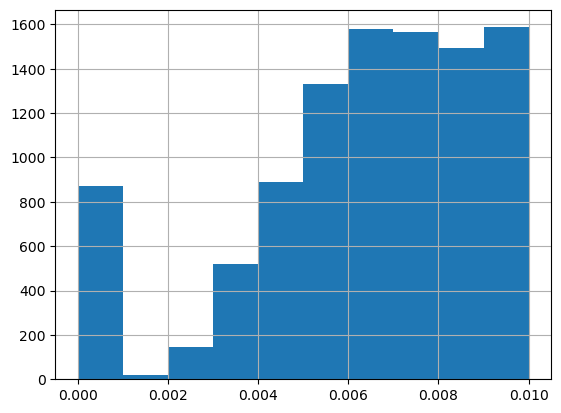

In [17]:
plt.hist(data_balanced_small['error_rate'])
plt.grid()
plt.show()

### now lets save the subsampled dataset as a loci list

In [18]:
data_balanced_small.head()

,chrom,pos,ref,coverage,non_ref_reads,error_rate
3155160,1,94545897,G,32,0,0.000000
1822183,1,39930809,C,125,1,0.008000
4773003,1,159175420,T,333,2,0.006006
5218774,1,170688919,G,111,1,0.009009
524116,1,12836041,G,79,0,0.000000


In [19]:
loci_list = data_balanced_small.iloc[:,[0,1]]

In [20]:
loci_list.head()

,chrom,pos
3155160,1,94545897
1822183,1,39930809
4773003,1,159175420
5218774,1,170688919
524116,1,12836041


In [21]:
loci_list.to_csv('loci_list.csv', index = False)